In [2]:
%load_ext autoreload
%autoreload 2

In [4]:
from pathlib import Path
import sys

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from src.io.zarr_loader import load_timepoint
from src.preprocessing.pipeline import preprocess_volume

from src.segmentation.thresholding import create_binary_mask
from src.segmentation.labeling import label_objects
from src.segmentation.statistics import calculate_object_statistics

In [11]:
SAMPLE_NAME = "44b6_0113de3b"

SAMPLE_ROOT = (
        PROJECT_ROOT
        / "data"
        / "sample"
        / "biohub_5samples_20timepoints"
        / "train"
        / SAMPLE_NAME
)

ZARR_PATH = (
        SAMPLE_ROOT
        / f"{SAMPLE_NAME}.zarr"
)

GROUND_TRUTH_DIR = (
        SAMPLE_ROOT
        / "ground_truth"
)

NODES_PATH = (
        GROUND_TRUTH_DIR
        / "ground_truth_nodes.csv"
)

EDGES_PATH = (
        GROUND_TRUTH_DIR
        / "ground_truth_edges.csv"
)

In [12]:
nodes_df = pd.read_csv(NODES_PATH)
edges_df = pd.read_csv(EDGES_PATH)

print("Ground-truth nodes:")
display(nodes_df)

print("Ground-truth edges:")
display(edges_df)

Ground-truth nodes:


,node_id,t,z,y,x
0,11000000075,0,63,222,249
1,12000000075,1,63,227,251
2,13000000075,2,63,230,253


Ground-truth edges:


,source_id,target_id
0,11000000075,12000000075
1,12000000075,13000000075


In [16]:
from src.pipelines.stage3 import run_stage3

timepoint = 0

binary_mask = run_stage3(
    zarr_path=ZARR_PATH,
    timepoint=timepoint
)

print(
    "Binary mask shape:",
    binary_mask.shape
)

Binary mask shape: (64, 256, 256)


In [22]:
# ---------------------------------------------------------
# Stage 3: Semantic segmentation
# ---------------------------------------------------------

binary_mask = run_stage3(
    ZARR_PATH,
    timepoint=0
)

print("Binary mask shape:", binary_mask.shape)


# ---------------------------------------------------------
# Connected-component labeling
# ---------------------------------------------------------

labeled_volume, num_objects = label_objects(
    binary_mask
)

print(
    "Labeled volume shape:",
    labeled_volume.shape
)

print(
    "Number of labeled objects:",
    num_objects
)


# ---------------------------------------------------------
# Calculate object statistics
# ---------------------------------------------------------

objects_df = calculate_object_statistics(
    labeled_volume
)

print(
    "Number of objects in statistics:",
    len(objects_df)
)

display(
    objects_df.head()
)

Binary mask shape: (64, 256, 256)
Labeled volume shape: (64, 256, 256)
Number of labeled objects: 147
Number of objects in statistics: 147


,object_id,volume,centroid_z,centroid_y,centroid_x
0,1,12888,11.416977,43.784839,89.659994
1,2,1,0.000000,14.000000,60.000000
2,3,1,0.000000,50.000000,84.000000
3,4,1,0.000000,52.000000,84.000000
4,5,11606,7.658022,86.640962,65.150612


In [23]:
from scipy.spatial.distance import cdist


def evaluate_detection(
        nodes_df,
        objects_df,
        timepoint=0,
        distance_threshold=10.0
):
    """
    Evaluate detected object centroids against ground-truth nodes.

    Parameters
    ----------
    nodes_df : pd.DataFrame
        Ground-truth node table containing:
        t, z, y, x

    objects_df : pd.DataFrame
        Detected object statistics containing:
        centroid_z, centroid_y, centroid_x

    timepoint : int
        Timepoint to evaluate.

    distance_threshold : float
        Maximum Euclidean distance in voxels for a detection
        to be considered a match.

    Returns
    -------
    results : dict
        Evaluation metrics and matching information.
    """

    # ---------------------------------------------------------
    # 1. Select ground-truth cells for this timepoint
    # ---------------------------------------------------------

    gt = nodes_df[
        nodes_df["t"] == timepoint
        ].copy()

    if len(gt) == 0:
        print(
            f"No ground-truth cells found at t={timepoint}"
        )

        return None

    # ---------------------------------------------------------
    # 2. Extract ground-truth coordinates
    # ---------------------------------------------------------

    gt_coords = gt[
        ["z", "y", "x"]
    ].to_numpy(
        dtype=float
    )

    # ---------------------------------------------------------
    # 3. Extract detected object centroids
    # ---------------------------------------------------------

    detected_coords = objects_df[
        [
            "centroid_z",
            "centroid_y",
            "centroid_x"
        ]
    ].to_numpy(
        dtype=float
    )

    # ---------------------------------------------------------
    # 4. Compute pairwise distances
    # ---------------------------------------------------------

    distances = cdist(
        gt_coords,
        detected_coords,
        metric="euclidean"
    )

    # ---------------------------------------------------------
    # 5. Find closest detection for each GT cell
    # ---------------------------------------------------------

    closest_indices = np.argmin(
        distances,
        axis=1
    )

    closest_distances = distances[
        np.arange(len(gt_coords)),
        closest_indices
    ]

    # ---------------------------------------------------------
    # 6. Determine detected / missed
    # ---------------------------------------------------------

    detected = (
            closest_distances
            <= distance_threshold
    )

    # ---------------------------------------------------------
    # 7. Calculate metrics
    # ---------------------------------------------------------

    true_positives = int(
        detected.sum()
    )

    false_negatives = (
            len(gt_coords)
            - true_positives
    )

    # Number of detected objects that were not matched
    matched_object_indices = set(
        closest_indices[detected]
    )

    false_positives = (
            len(detected_coords)
            - len(matched_object_indices)
    )

    precision = (
        true_positives
        / (true_positives + false_positives)
        if (true_positives + false_positives) > 0
        else 0.0
    )

    recall = (
        true_positives
        / (true_positives + false_negatives)
        if (true_positives + false_negatives) > 0
        else 0.0
    )

    # ---------------------------------------------------------
    # 8. Build matching table
    # ---------------------------------------------------------

    matching_df = gt[
        ["node_id", "t", "z", "y", "x"]
    ].copy()

    matching_df[
        "matched_object_id"
    ] = objects_df.iloc[
        closest_indices
    ]["object_id"].to_numpy()

    matching_df[
        "distance"
    ] = closest_distances

    matching_df[
        "detected"
    ] = detected

    # ---------------------------------------------------------
    # 9. Return results
    # ---------------------------------------------------------

    return {
        "timepoint": timepoint,
        "ground_truth_count": len(gt_coords),
        "detected_object_count": len(detected_coords),
        "true_positives": true_positives,
        "false_negatives": false_negatives,
        "false_positives": false_positives,
        "precision": precision,
        "recall": recall,
        "matching": matching_df
    }

In [24]:
results = evaluate_detection(
    nodes_df=nodes_df,
    objects_df=objects_df,
    timepoint=0,
    distance_threshold=10.0
)

In [25]:
print("=" * 60)
print("STAGE 5 — DETECTION EVALUATION")
print("=" * 60)

print(
    "Timepoint:",
    results["timepoint"]
)

print(
    "Ground-truth cells:",
    results["ground_truth_count"]
)

print(
    "Detected objects:",
    results["detected_object_count"]
)

print(
    "True positives:",
    results["true_positives"]
)

print(
    "False positives:",
    results["false_positives"]
)

print(
    "False negatives:",
    results["false_negatives"]
)

print(
    "Precision:",
    f"{results['precision'] * 100:.2f}%"
)

print(
    "Recall:",
    f"{results['recall'] * 100:.2f}%"
)

STAGE 5 — DETECTION EVALUATION
Timepoint: 0
Ground-truth cells: 1
Detected objects: 147
True positives: 1
False positives: 146
False negatives: 0
Precision: 0.68%
Recall: 100.00%


In [26]:
display(
    results["matching"]
)

,node_id,t,z,y,x,matched_object_id,distance,detected
0,11000000075,0,63,222,249,140,8.017161,True


Run Stage 3 for each timepoint

In [27]:
all_results = []

for t in sorted(nodes_df["t"].unique()):

    print(
        f"\nProcessing timepoint {t}..."
    )

    # Run Stage 3
    binary_mask = run_stage3(
        ZARR_PATH,
        timepoint=int(t)
    )

    # Connected components
    labeled_volume, num_objects = label_objects(
        binary_mask
    )

    # Object statistics
    objects_df = calculate_object_statistics(
        labeled_volume
    )

    # Evaluate
    results = evaluate_detection(
        nodes_df=nodes_df,
        objects_df=objects_df,
        timepoint=int(t),
        distance_threshold=10.0
    )

    all_results.append(
        results
    )


Processing timepoint 0...

Processing timepoint 1...

Processing timepoint 2...


In [28]:
summary = pd.DataFrame([
    {
        "timepoint": r["timepoint"],
        "ground_truth": r["ground_truth_count"],
        "detected_objects": r["detected_object_count"],
        "true_positives": r["true_positives"],
        "false_positives": r["false_positives"],
        "false_negatives": r["false_negatives"],
        "precision": r["precision"],
        "recall": r["recall"]
    }
    for r in all_results
])

display(summary)

,timepoint,ground_truth,detected_objects,true_positives,false_positives,false_negatives,precision,recall
0,0,1,147,1,146,0,0.006803,1.0
1,1,1,135,1,134,0,0.007407,1.0
2,2,1,141,0,141,1,0.000000,0.0


Cell tracking

In [29]:
def get_detections(
        zarr_path,
        timepoint
):
    """
    Run Stage 3 and extract object centroids
    for one timepoint.
    """

    # Stage 3 semantic segmentation
    binary_mask = run_stage3(
        zarr_path,
        timepoint=timepoint
    )

    # Connected components
    labeled_volume, num_objects = label_objects(
        binary_mask
    )

    # Object statistics
    objects_df = calculate_object_statistics(
        labeled_volume
    )

    return objects_df

In [30]:
detections_t0 = get_detections(
    ZARR_PATH,
    timepoint=0
)

print(
    detections_t0.head()
)

print(
    "Number of detections:",
    len(detections_t0)
)

   object_id  volume  centroid_z  centroid_y  centroid_x
0          1   12888   11.416977   43.784839   89.659994
1          2       1    0.000000   14.000000   60.000000
2          3       1    0.000000   50.000000   84.000000
3          4       1    0.000000   52.000000   84.000000
4          5   11606    7.658022   86.640962   65.150612
Number of detections: 147


In [31]:
detections_t0 = get_detections(
    ZARR_PATH,
    timepoint=0
)

detections_t1 = get_detections(
    ZARR_PATH,
    timepoint=1
)

print(
    "t=0 detections:",
    len(detections_t0)
)

print(
    "t=1 detections:",
    len(detections_t1)
)

t=0 detections: 147
t=1 detections: 135


In [32]:
centroids_t0 = detections_t0[
    [
        "centroid_z",
        "centroid_y",
        "centroid_x"
    ]
].to_numpy()

centroids_t1 = detections_t1[
    [
        "centroid_z",
        "centroid_y",
        "centroid_x"
    ]
].to_numpy()

In [33]:
distances = cdist(
    centroids_t0,
    centroids_t1,
    metric="euclidean"
)

print(
    "Distance matrix shape:",
    distances.shape
)

Distance matrix shape: (147, 135)


In [34]:
nearest_indices = np.argmin(
    distances,
    axis=1
)

nearest_distances = np.min(
    distances,
    axis=1
)

In [35]:
tracking_df = pd.DataFrame({
    "object_id_t0":
        detections_t0[
            "object_id"
        ].to_numpy(),

    "object_id_t1":
        detections_t1.iloc[
            nearest_indices
        ][
            "object_id"
        ].to_numpy(),

    "distance":
        nearest_distances
})

In [36]:
display(
    tracking_df.head(20)
)

,object_id_t0,object_id_t1,distance
0,1,2,14.694753
1,2,17,33.056807
2,3,2,0.852657
3,4,2,1.382826
4,5,1,26.791156
5,6,2,3.331275
6,7,3,8.143298
7,8,4,1.449762
8,9,5,9.319326
9,10,7,3.848370


Hungarian Assignment

In [37]:
from scipy.optimize import linear_sum_assignment

In [38]:
def match_detections(
        detections_t0,
        detections_t1,
        max_distance=10.0
):
    """
    Match cell detections between two consecutive
    timepoints using the Hungarian algorithm.

    Parameters
    ----------
    detections_t0 : pandas.DataFrame
        Detections at timepoint t.

    detections_t1 : pandas.DataFrame
        Detections at timepoint t+1.

    max_distance : float
        Maximum allowed centroid displacement in voxels.

    Returns
    -------
    matches : pandas.DataFrame
        Matched detection pairs.
    """

    # ---------------------------------------------------------
    # Extract centroids
    # ---------------------------------------------------------

    centroids_t0 = detections_t0[
        [
            "centroid_z",
            "centroid_y",
            "centroid_x"
        ]
    ].to_numpy()

    centroids_t1 = detections_t1[
        [
            "centroid_z",
            "centroid_y",
            "centroid_x"
        ]
    ].to_numpy()

    # ---------------------------------------------------------
    # Calculate pairwise distances
    # ---------------------------------------------------------

    distances = cdist(
        centroids_t0,
        centroids_t1,
        metric="euclidean"
    )

    # ---------------------------------------------------------
    # Hungarian assignment
    # ---------------------------------------------------------

    row_indices, col_indices = linear_sum_assignment(
        distances
    )

    # ---------------------------------------------------------
    # Build matches
    # ---------------------------------------------------------

    matches = []

    for row, col in zip(
            row_indices,
            col_indices
    ):

        distance = distances[
            row,
            col
        ]

        # Apply maximum displacement constraint
        if distance <= max_distance:

            matches.append({
                "object_id_t0":
                    detections_t0.iloc[
                        row
                    ][
                        "object_id"
                    ],

                "object_id_t1":
                    detections_t1.iloc[
                        col
                    ][
                        "object_id"
                    ],

                "distance":
                    distance
            })

    return pd.DataFrame(
        matches
    )

In [39]:
matches_t0_t1 = match_detections(
    detections_t0,
    detections_t1,
    max_distance=10.0
)

In [40]:
print(
    "Number of matches:",
    len(matches_t0_t1)
)

display(
    matches_t0_t1.head(20)
)

Number of matches: 90


,object_id_t0,object_id_t1,distance
0,3.0,2.0,0.852657
1,8.0,4.0,1.449762
2,12.0,18.0,7.413751
3,13.0,21.0,5.088686
4,14.0,9.0,3.098113
5,15.0,11.0,9.013791
6,16.0,10.0,4.656295
7,17.0,14.0,2.869090
8,19.0,13.0,5.327871
9,20.0,15.0,3.748203


Track IDs

In [41]:
def initialize_tracks(
        detections
):
    """
    Initialize tracks at the first timepoint.
    """

    tracks = detections.copy()

    tracks["track_id"] = np.arange(
        len(tracks)
    )

    tracks["timepoint"] = 0

    return tracks

In [42]:
print(
    matches_t0_t1[
        "distance"
    ].describe()
)

count    90.000000
mean      4.596697
std       2.082605
min       0.852657
25%       3.099749
50%       4.318298
75%       5.551556
max       9.769369
Name: distance, dtype: float64


Track cells across all timepoints

In [43]:
def get_all_detections(
        zarr_path,
        num_timepoints
):
    """
    Run Stage 3 segmentation and connected-component
    analysis for every timepoint.

    Returns
    -------
    detections_by_time : dict
        Dictionary mapping timepoint -> detections DataFrame.
    """

    detections_by_time = {}

    for t in range(num_timepoints):

        print(
            f"Processing timepoint {t}..."
        )

        detections = get_detections(
            zarr_path,
            timepoint=t
        )

        detections["timepoint"] = t

        detections_by_time[t] = detections

        print(
            f"  Detected objects: {len(detections)}"
        )

    return detections_by_time

In [44]:
detections_by_time = get_all_detections(
    ZARR_PATH,
    num_timepoints=20
)

Processing timepoint 0...
  Detected objects: 147
Processing timepoint 1...
  Detected objects: 135
Processing timepoint 2...
  Detected objects: 141
Processing timepoint 3...
  Detected objects: 139
Processing timepoint 4...
  Detected objects: 140
Processing timepoint 5...
  Detected objects: 149
Processing timepoint 6...
  Detected objects: 146
Processing timepoint 7...
  Detected objects: 142
Processing timepoint 8...
  Detected objects: 131
Processing timepoint 9...
  Detected objects: 151
Processing timepoint 10...
  Detected objects: 135
Processing timepoint 11...
  Detected objects: 140
Processing timepoint 12...
  Detected objects: 142
Processing timepoint 13...
  Detected objects: 129
Processing timepoint 14...
  Detected objects: 127
Processing timepoint 15...
  Detected objects: 129
Processing timepoint 16...
  Detected objects: 133
Processing timepoint 17...
  Detected objects: 140
Processing timepoint 18...
  Detected objects: 149
Processing timepoint 19...
  Detected obj

In [45]:
for t, df in detections_by_time.items():

    print(
        f"t={t}: {len(df)} objects"
    )

t=0: 147 objects
t=1: 135 objects
t=2: 141 objects
t=3: 139 objects
t=4: 140 objects
t=5: 149 objects
t=6: 146 objects
t=7: 142 objects
t=8: 131 objects
t=9: 151 objects
t=10: 135 objects
t=11: 140 objects
t=12: 142 objects
t=13: 129 objects
t=14: 127 objects
t=15: 129 objects
t=16: 133 objects
t=17: 140 objects
t=18: 149 objects
t=19: 149 objects


Build the complete tracker

In [48]:
def track_detections(
        detections_by_time,
        max_distance=10.0
):
    """
    Track objects across consecutive timepoints
    using Hungarian assignment.

    Parameters
    ----------
    detections_by_time : dict
        Dictionary mapping timepoint to detections DataFrame.

    max_distance : float
        Maximum allowed centroid displacement in voxels.

    Returns
    -------
    tracks : pandas.DataFrame
        All detections with persistent track IDs.
    """

    # ---------------------------------------------------------
    # Sort timepoints
    # ---------------------------------------------------------

    timepoints = sorted(
        detections_by_time.keys()
    )

    if len(timepoints) == 0:
        return pd.DataFrame()

    # ---------------------------------------------------------
    # Initialize first timepoint
    # ---------------------------------------------------------

    first_timepoint = timepoints[0]

    previous = (
        detections_by_time[
            first_timepoint
        ]
        .copy()
        .reset_index(drop=True)
    )

    # Assign a unique track ID to every object
    previous["track_id"] = np.arange(
        len(previous)
    )

    previous["timepoint"] = (
        first_timepoint
    )

    # Store all results
    all_tracks = [
        previous.copy()
    ]

    # Next available track ID
    next_track_id = len(
        previous
    )

    # ---------------------------------------------------------
    # Process consecutive timepoints
    # ---------------------------------------------------------

    for t in timepoints[1:]:

        print(
            f"Tracking: "
            f"t={t-1} → t={t}"
        )

        current = (
            detections_by_time[
                t
            ]
            .copy()
            .reset_index(drop=True)
        )

        current["timepoint"] = t

        # -----------------------------------------------------
        # Extract centroids
        # -----------------------------------------------------

        previous_centroids = (
            previous[
                [
                    "centroid_z",
                    "centroid_y",
                    "centroid_x"
                ]
            ]
            .to_numpy()
        )

        current_centroids = (
            current[
                [
                    "centroid_z",
                    "centroid_y",
                    "centroid_x"
                ]
            ]
            .to_numpy()
        )

        # -----------------------------------------------------
        # Handle empty detections
        # -----------------------------------------------------

        if (
                len(previous_centroids) == 0
                or len(current_centroids) == 0
        ):

            current["track_id"] = np.arange(
                next_track_id,
                next_track_id + len(current)
            )

            next_track_id += len(current)

            all_tracks.append(
                current.copy()
            )

            previous = current.copy()

            continue

        # -----------------------------------------------------
        # Calculate pairwise distances
        # -----------------------------------------------------

        distances = cdist(
            previous_centroids,
            current_centroids,
            metric="euclidean"
        )

        # -----------------------------------------------------
        # Hungarian assignment
        # -----------------------------------------------------

        row_indices, col_indices = (
            linear_sum_assignment(
                distances
            )
        )

        # -----------------------------------------------------
        # Initialize all current objects
        # as unmatched
        # -----------------------------------------------------

        current["track_id"] = -1

        assigned_current = set()

        # -----------------------------------------------------
        # Assign matched objects
        # -----------------------------------------------------

        for row, col in zip(
                row_indices,
                col_indices
        ):

            distance = distances[
                row,
                col
            ]

            # Only accept physically plausible movement
            if distance <= max_distance:

                track_id = previous.iloc[
                    row
                ]["track_id"]

                current.iloc[
                    col,
                    current.columns.get_loc(
                        "track_id"
                    )
                ] = track_id

                assigned_current.add(
                    col
                )

        # -----------------------------------------------------
        # Create new tracks for unmatched objects
        # -----------------------------------------------------

        for index in range(
                len(current)
        ):

            if index not in assigned_current:

                current.iloc[
                    index,
                    current.columns.get_loc(
                        "track_id"
                    )
                ] = next_track_id

                next_track_id += 1

        # -----------------------------------------------------
        # Store current timepoint
        # -----------------------------------------------------

        all_tracks.append(
            current.copy()
        )

        # -----------------------------------------------------
        # IMPORTANT:
        # Current becomes previous for next iteration
        # and now contains track_id
        # -----------------------------------------------------

        previous = current.copy()

    # ---------------------------------------------------------
    # Combine all timepoints
    # ---------------------------------------------------------

    tracks = pd.concat(
        all_tracks,
        ignore_index=True
    )

    return tracks

In [49]:
tracks = track_detections(
    detections_by_time,
    max_distance=10.0
)

Tracking: t=0 → t=1
Tracking: t=1 → t=2
Tracking: t=2 → t=3
Tracking: t=3 → t=4
Tracking: t=4 → t=5
Tracking: t=5 → t=6
Tracking: t=6 → t=7
Tracking: t=7 → t=8
Tracking: t=8 → t=9
Tracking: t=9 → t=10
Tracking: t=10 → t=11
Tracking: t=11 → t=12
Tracking: t=12 → t=13
Tracking: t=13 → t=14
Tracking: t=14 → t=15
Tracking: t=15 → t=16
Tracking: t=16 → t=17
Tracking: t=17 → t=18
Tracking: t=18 → t=19


In [50]:
print(
    tracks.head(20)
)

    object_id  volume  centroid_z  centroid_y  centroid_x  timepoint  track_id
0           1   12888   11.416977   43.784839   89.659994          0         0
1           2       1    0.000000   14.000000   60.000000          0         1
2           3       1    0.000000   50.000000   84.000000          0         2
3           4       1    0.000000   52.000000   84.000000          0         3
4           5   11606    7.658022   86.640962   65.150612          0         4
5           6       3    0.000000   54.000000   84.000000          0         5
6           7    1040    1.623077   87.295192   89.882692          0         6
7           8     483    0.519669   98.387164   35.571429          0         7
8           9      59    0.000000  108.355932   75.152542          0         8
9          10     954    1.002096  127.156184   71.339623          0         9
10         11    1290    2.448837  146.225581   46.864341          0        10
11         12    1000    1.954000  147.183000  106.8

In [51]:
track_lengths = (
    tracks
    .groupby(
        "track_id"
    )
    ["timepoint"]
    .nunique()
    .sort_values(
        ascending=False
    )
)

In [52]:
print(
    track_lengths.head(20)
)

track_id
47     16
86     16
128    14
54     13
25     12
16     12
19     12
134    12
225    12
344    12
114    11
56     11
135    11
539    10
606    10
232    10
349    10
429    10
211    10
255    10
Name: timepoint, dtype: int64


Find long-lived tracks

In [53]:
long_tracks = (
    track_lengths[
        track_lengths >= 5
        ]
    .index
)

In [54]:
long_track_data = tracks[
    tracks[
        "track_id"
    ].isin(
        long_tracks
    )
]

In [55]:
print(
    "Total tracks:",
    tracks[
        "track_id"
    ].nunique()
)

print(
    "Long-lived tracks:",
    len(
        long_tracks
    )
)

Total tracks: 1131
Long-lived tracks: 138


3D trajectory visualization

In [56]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


def plot_3d_tracks(
        tracks,
        min_track_length=3
):
    """
    Visualize cell/object trajectories in 3D.

    Parameters
    ----------
    tracks : pandas.DataFrame
        Tracking results containing:
        track_id, timepoint,
        centroid_z, centroid_y, centroid_x

    min_track_length : int
        Minimum number of timepoints required
        for a track to be visualized.
    """

    # ---------------------------------------------------------
    # Calculate track lengths
    # ---------------------------------------------------------

    track_lengths = (
        tracks
        .groupby("track_id")
        ["timepoint"]
        .nunique()
    )

    # Keep only sufficiently long tracks
    valid_track_ids = track_lengths[
        track_lengths >= min_track_length
        ].index

    filtered_tracks = tracks[
        tracks["track_id"].isin(
            valid_track_ids
        )
    ]

    print(
        "Total tracks:",
        tracks["track_id"].nunique()
    )

    print(
        "Tracks visualized:",
        len(valid_track_ids)
    )

    # ---------------------------------------------------------
    # Create 3D figure
    # ---------------------------------------------------------

    fig = plt.figure(
        figsize=(12, 10)
    )

    ax = fig.add_subplot(
        111,
        projection="3d"
    )

    # ---------------------------------------------------------
    # Plot each trajectory
    # ---------------------------------------------------------

    for track_id, track in (
            filtered_tracks
                    .groupby("track_id")
    ):

        track = track.sort_values(
            "timepoint"
        )

        ax.plot(
            track["centroid_x"],
            track["centroid_y"],
            track["centroid_z"],
            linewidth=1.5,
            alpha=0.7
        )

        # Start point
        ax.scatter(
            track.iloc[0]["centroid_x"],
            track.iloc[0]["centroid_y"],
            track.iloc[0]["centroid_z"],
            s=30
        )

    # ---------------------------------------------------------
    # Labels
    # ---------------------------------------------------------

    ax.set_xlabel(
        "X"
    )

    ax.set_ylabel(
        "Y"
    )

    ax.set_zlabel(
        "Z"
    )

    ax.set_title(
        "3D Cell/Object Trajectories"
    )

    # ---------------------------------------------------------
    # Reverse Z axis
    # ---------------------------------------------------------

    ax.invert_zaxis()

    plt.tight_layout()

    plt.show()

Total tracks: 1131
Tracks visualized: 408


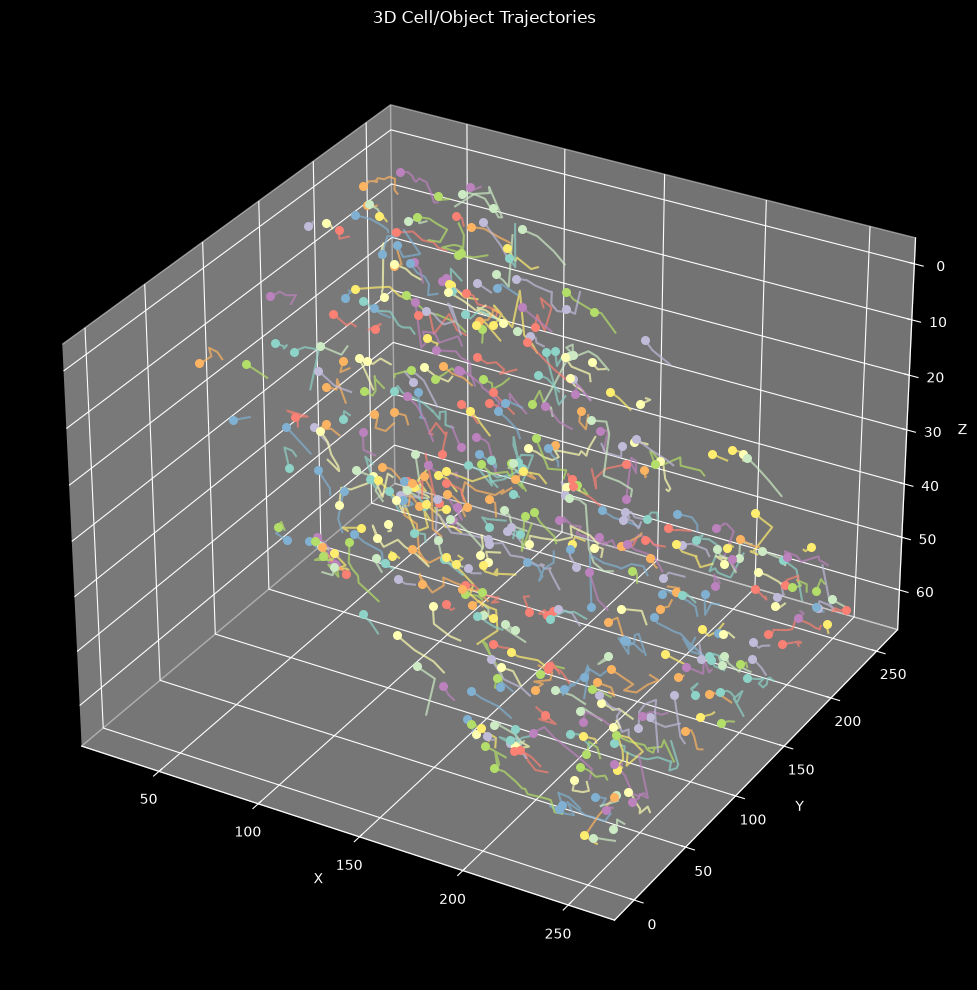

In [57]:
plot_3d_tracks(
    tracks,
    min_track_length=3
)